# Versão 4 - Visão Geral dos Dados e Hipóteses de Melhoria

A versão 4 nasce a partir do que aprendemos com a versão 3. O pipeline anterior já era funcional e conseguiu superar a baseline de persistência no agregado, mas deixou sinais claros de onde o projeto ainda pode melhorar:

- a base é desbalanceada entre classes;
- algumas classes como `6`, `7` e `9` parecem mais difíceis;
- algumas variáveis têm amplitude muito alta e podem prejudicar a estabilidade numérica;
- a versão 3 usou um modelo híbrido, então ainda faltava uma comparação didática com uma LSTM mais "pura";
- a previsão de um único passo à frente foi útil, mas a versão 4 vai preparar o terreno para previsão multi-step.

Este notebook revisita a base com esse olhar: entender a escala do problema e levantar indícios que justificam as decisões da nova versão.


## 1. Preparação do ambiente

Primeiro carregamos bibliotecas e funções auxiliares do `pipeline_v4.py`. Esse arquivo concentra a lógica nova da versão 4, mas ainda reaproveita partes estáveis da versão 3 para manter compatibilidade e reduzir retrabalho.


In [1]:
from __future__ import annotations

#resolve os caminhos para importar o pipeline_v4 de forma robusta
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()
CANDIDATE_DIRS = [
    CURRENT_DIR,
    CURRENT_DIR / "versao4",
    CURRENT_DIR.parent / "versao4",
]
NOTEBOOK_DIR = next((candidate for candidate in CANDIDATE_DIRS if (candidate / "pipeline_v4.py").exists()), CURRENT_DIR)
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "versao4" else NOTEBOOK_DIR
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

#carrega bibliotecas para tabelas e visualizacao
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

#importa apenas as funcoes usadas neste notebook
from pipeline_v4 import (
    AUX_ANALOG_COLUMNS,
    BASE_TARGET_COLUMNS,
    collect_training_reference_frame,
    discover_all_dataset_files,
    profile_continuous_columns,
    recommend_log_transform_columns,
    set_seed,
    split_manifest_by_series,
)

#fixa a semente para manter reproducibilidade nas amostras e tabelas
set_seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


## 2. Definição de caminhos e parâmetros de leitura

Vamos apontar para a pasta `3W/dataset` e também definir um limite de amostragem para montar um quadro de referência numérico. Esse limite é importante porque queremos inspecionar o comportamento das colunas sem precisar carregar todas as linhas de treino em memória ao mesmo tempo.


In [2]:
#define os caminhos principais do projeto
DATASET_ROOT = PROJECT_ROOT / "3W" / "dataset"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
REPORTS_V4_DIR = ARTIFACTS_DIR / "reports_v4"
REPORTS_V4_DIR.mkdir(parents=True, exist_ok=True)

#define quantas linhas por serie serao usadas no quadro de referencia numerico
REFERENCE_ROWS_PER_SERIES = 512

pd.DataFrame(
    {
        "configuracao": ["dataset_root", "reports_v4_dir", "reference_rows_per_series"],
        "valor": [str(DATASET_ROOT), str(REPORTS_V4_DIR), REFERENCE_ROWS_PER_SERIES],
    }
)


,configuracao,valor
0,dataset_root,/home/tiagoriosrocha/Desktop/lstm-w3/3W/dataset
1,reports_v4_dir,/home/tiagoriosrocha/Desktop/lstm-w3/artifacts...
2,reference_rows_per_series,512


## 3. Manifesto geral do dataset

O manifesto é uma tabela que lista todos os arquivos da base com metadados úteis, como classe, poço, origem e caminho do arquivo. Ele é o ponto de partida para quase todo o pipeline, porque permite dividir a base e auditar o que foi usado em cada experimento.


In [3]:
#descobre todos os arquivos parquet do dataset e cria um manifesto unico
manifest_df = discover_all_dataset_files(DATASET_ROOT)

#resume a escala geral do problema para orientar as decisoes da versao4
overview_df = pd.DataFrame(
    {
        "aspecto": ["arquivos", "classes", "wells", "origens"],
        "valor": [
            len(manifest_df),
            manifest_df["class_label"].nunique(),
            manifest_df["well_name"].nunique(),
            manifest_df["source_type"].nunique(),
        ],
    }
)

class_distribution_df = (
    manifest_df.groupby("class_label", as_index=False)
    .agg(arquivos=("series_id", "count"), wells=("well_name", "nunique"))
    .sort_values("arquivos", ascending=False)
)

source_distribution_df = (
    manifest_df.groupby("source_type", as_index=False)
    .agg(arquivos=("series_id", "count"))
    .sort_values("arquivos", ascending=False)
)

display(overview_df)
display(class_distribution_df)
display(source_distribution_df)
manifest_df.head()


,aspecto,valor
0,arquivos,2228
1,classes,10
2,wells,42
3,origens,3


,class_label,arquivos,wells
0,0,594,9
5,5,450,4
4,4,343,7
6,6,221,3
9,9,207,16
1,1,128,5
3,3,106,3
8,8,95,10
7,7,46,7
2,2,38,8


,source_type,arquivos
2,well,1119
1,simulated,1089
0,drawn,20


,class_label,well_name,start_token,series_id,source_type,file_path
0,0,WELL-00001,20170201010207,0__WELL-00001_20170201010207,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...
1,0,WELL-00001,20170201060114,0__WELL-00001_20170201060114,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...
2,0,WELL-00001,20170201110124,0__WELL-00001_20170201110124,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...
3,0,WELL-00001,20170201160311,0__WELL-00001_20170201160311,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...
4,0,WELL-00001,20170201210228,0__WELL-00001_20170201210228,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...


### Leitura desta execução

Nesta execução, as classes `0`, `5` e `4` concentraram a maior parte dos arquivos, enquanto `2` e `7` apareceram poucas vezes. Isso é importante porque, em problemas de séries temporais, o número de arquivos funciona como uma aproximação da diversidade de cenários observados pelo modelo.

Também chama atenção o quase equilíbrio entre arquivos `well` e `simulated`, enquanto `drawn` aparece só 20 vezes. Na prática, isso significa que qualquer conclusão sobre o comportamento dos dados desenhados precisa ser vista com cuidado, porque a amostra é muito pequena.


### Como interpretar essa etapa

Se algumas classes aparecem em muito mais arquivos do que outras, o modelo recebe mais exemplos daqueles comportamentos e tende a aprender melhor esses padrões. Isso não significa que as classes minoritárias são impossíveis de prever, mas significa que precisamos cuidar melhor da amostragem e da avaliação.

Na versão 3, o teste final mostrou que algumas classes eram mais difíceis. Por isso, a versão 4 vai acompanhar a distribuição por classe desde o começo e também incluir uma amostragem mais balanceada durante o treino.


## 4. Prévia da divisão em treino, validação e teste

Antes mesmo de pré-processar a base, já vale enxergar como a divisão temporal por séries vai ficar. Isso evita surpresas como um split quase sem exemplos de alguma classe ou um conjunto de teste muito diferente do restante.


In [4]:
#simula a divisao por series que sera usada no pre processamento da versao4
split_manifest_df = split_manifest_by_series(manifest_df, train_frac=0.7, validation_frac=0.15)

split_overview_df = (
    split_manifest_df.groupby(["split", "class_label"], as_index=False)
    .agg(arquivos=("series_id", "count"), wells=("well_name", "nunique"))
    .sort_values(["split", "class_label"])
)

hard_classes_df = split_overview_df[split_overview_df["class_label"].isin(["6", "7", "9"])].copy()

display(split_overview_df)
display(hard_classes_df)


,split,class_label,arquivos,wells
0,test,0,96,7
1,test,1,20,2
2,test,2,7,3
3,test,3,18,2
4,test,4,57,7
5,test,5,69,3
6,test,6,35,3
7,test,7,9,4
8,test,8,15,3
9,test,9,34,11


,split,class_label,arquivos,wells
6,test,6,35,3
7,test,7,9,4
9,test,9,34,11
16,train,6,154,3
17,train,7,32,7
19,train,9,144,16
26,validation,6,32,1
27,validation,7,5,4
29,validation,9,29,8


### O que a divisão já antecipa

Todos os três splits preservaram as 10 classes, o que é um bom sinal para avaliação. Mesmo assim, algumas fatias continuam frágeis: a classe `7` ficou com apenas 5 arquivos na validação e 9 no teste, e a classe `6` apareceu com apenas 1 poço na validação.

Em termos didáticos, isso quer dizer que métricas por classe na validação podem oscilar bastante de uma execução para outra. A validação continua útil, mas não deve ser tratada como verdade absoluta quando a classe é rara ou concentrada em poucos poços.


Agora nós conectamos duas leituras importantes: a estrutura global da base e a futura divisão do experimento. Se uma classe difícil já é rara no manifesto e continua rara dentro de treino e validação, isso reforça a necessidade de um treino mais cuidadoso.


## 5. Perfil numérico das variáveis contínuas

Aqui começamos a investigar o ponto que mais motivou mudanças no pré-processamento da versão 4: a presença de colunas com escala muito alta. Em vez de olhar apenas médias e desvios, vamos montar um perfil com quantis e uma regra simples que sugere quando uma transformação logarítmica pode ajudar.


In [5]:
#monta um dataframe de referencia com amostras das series de treino para inspecao numerica
train_manifest_df = split_manifest_df.loc[split_manifest_df["split"] == "train"].reset_index(drop=True)
training_reference_df = collect_training_reference_frame(
    train_manifest_df,
    max_rows_per_series=REFERENCE_ROWS_PER_SERIES,
)

#resume a amplitude das variaveis continuas e sugere transformacoes logaritmicas quando fizer sentido
continuous_profile_df = profile_continuous_columns(training_reference_df)
recommended_log_columns = recommend_log_transform_columns(
    continuous_profile_df,
    candidate_columns=AUX_ANALOG_COLUMNS,
)

display(continuous_profile_df)
recommended_log_columns


,column,non_null_rows,min,p01,p50,p99,max,iqr,positive_pct,zero_pct,dynamic_ratio_p99_p50,recommended_log_transform
0,P-ANULAR,795648,-6.787609e+06,0.000,0.000000e+00,2.361392e+07,4.146449e+07,1.474274e+07,41.249020,58.558559,2.361392e+13,False
1,P-JUS-CKGL,795648,-4.976717e+05,-497338.353,0.000000e+00,3.999996e+07,1.051946e+10,3.653325e+06,35.637242,62.355212,3.999996e+13,False
2,P-MON-CKP,795648,-9.837860e+04,0.000,2.127995e+06,1.228654e+07,2.024212e+07,4.977963e+06,82.170256,17.824968,5.773764e+00,False
3,P-PDG,795648,-1.180116e+42,0.000,1.888684e+07,4.485805e+07,4.909423e+07,2.448948e+07,61.185097,38.560268,2.375096e+00,False
4,P-TPT,795648,-1.712930e+07,0.000,1.455984e+07,2.843596e+07,2.941990e+09,8.625191e+06,92.084942,7.528958,1.953041e+00,False
5,QGL,795648,-1.940544e+01,0.000,0.000000e+00,4.487683e+00,6.699317e+00,0.000000e+00,12.877177,86.953276,4.487683e+06,False
6,T-JUS-CKP,795648,-1.139260e+01,0.000,6.722766e+01,1.013075e+02,1.082590e+02,7.994782e+01,74.903098,25.032175,1.506931e+00,False
7,T-PDG,795648,-1.711613e+38,0.000,0.000000e+00,1.181585e+02,3.000000e+04,0.000000e+00,16.395818,83.349547,1.181585e+08,False
8,T-TPT,795648,-3.375000e+01,0.000,1.108945e+02,1.258607e+02,1.277401e+02,5.839661e+01,86.293311,13.513514,1.134959e+00,False


[]

### Leitura do perfil contínuo desta execução

Os perfis numéricos confirmam que várias colunas têm amplitude extrema, mas também mostram por que nenhuma transformação logarítmica foi ativada automaticamente. O critério adotado foi conservador e exigia predominância forte de valores positivos; como `P-ANULAR`, `P-JUS-CKGL`, `QGL` e `T-PDG` têm muitos zeros ou sinais mistos, a heurística preferiu não aplicar log.

Isso é um ponto importante para iniciantes: nem todo valor muito grande deve virar log imediatamente. Quando existem muitos zeros ou valores negativos, a transformação pode dificultar a interpretação física da variável. Por isso, a versão 4 ficou com `clipping` + escalonamento robusto como solução mais segura.


### O que significa uma recomendação de log aqui

Uma transformação logarítmica não é uma "correção mágica". Ela apenas comprime escalas muito amplas, diminuindo o peso de valores extremos. Isso costuma ajudar quando uma variável é sempre positiva e possui poucos valores muito grandes comparados ao restante.

A versão 4 vai usar essa leitura para decidir quais colunas auxiliares analógicas podem ser tratadas com `log1p` antes da normalização. O objetivo não é mudar o significado físico da variável, e sim facilitar o trabalho do modelo e reduzir instabilidade numérica.


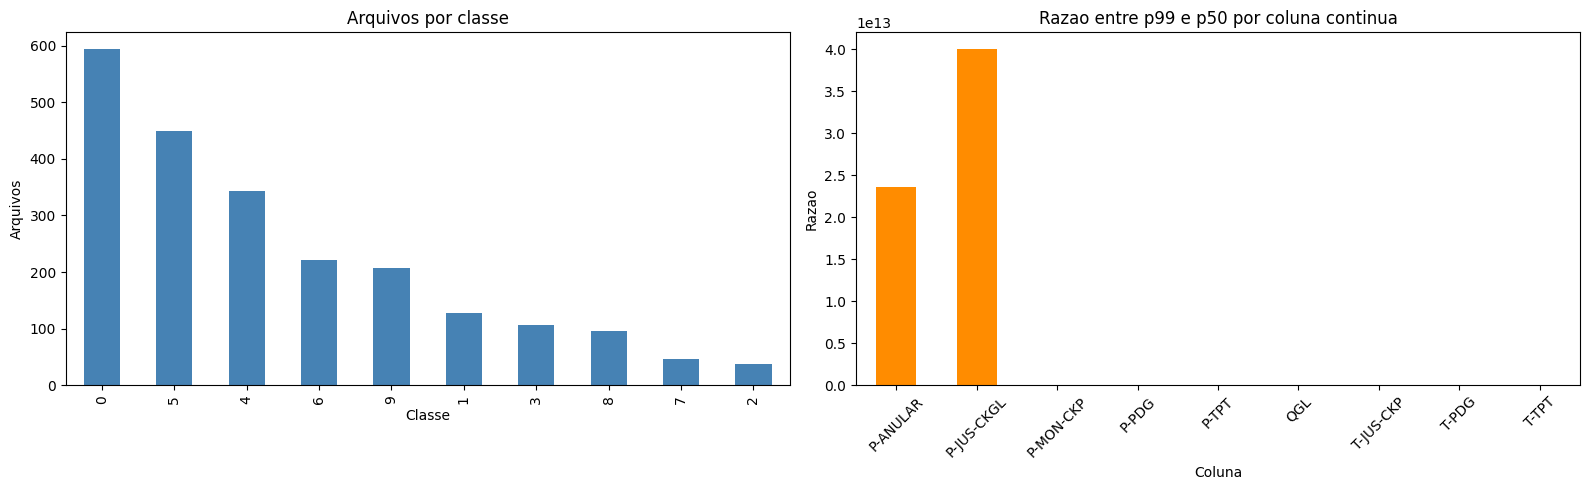

In [6]:
#gera graficos simples para visualizar desbalanceamento e amplitude numerica
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

class_distribution_df.set_index("class_label")["arquivos"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Arquivos por classe")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Arquivos")

continuous_profile_df.set_index("column")["dynamic_ratio_p99_p50"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Razao entre p99 e p50 por coluna continua")
axes[1].set_xlabel("Coluna")
axes[1].set_ylabel("Razao")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## Conclusão da etapa

A leitura exploratória da versão 4 não substitui a da versão 3; ela a complementa. Agora temos três justificativas concretas para as mudanças que virão:

1. a base é desbalanceada, então a amostragem de janelas precisa ser mais consciente;
2. algumas colunas têm escala extrema, então a normalização deve ser mais robusta;
3. as classes difíceis merecem monitoramento explícito durante treino e teste.

Com isso em mente, o próximo notebook vai preparar os dados com escalonamento robusto, possibilidade de transformação logarítmica e recomendação de horizonte multi-step.
